In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
import json
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
 
from xcube.core.store import new_data_store
from xcube.core.chunk import chunk_dataset
from xcube.core.gridmapping import GridMapping
from xcube.core.geom import mask_dataset_by_geometry
from xcube_resampling.spatial import resample_in_space
from xcube_resampling.gridmapping import GridMapping

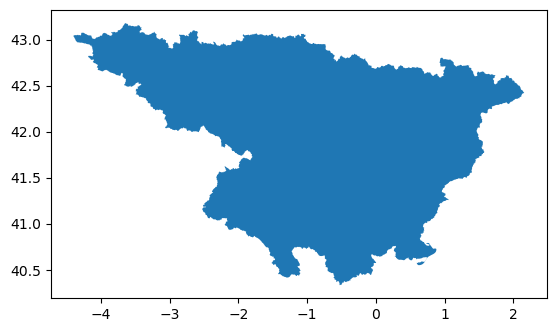

In [2]:
gdf = gpd.read_file("ebro_data/Limite_Cuenca_Ebro84.shp")
gdf.plot()
plt.show()

In [3]:
bbox = [-5, 40, 3, 44] # Ebro Basin
time_range = ("2020-01-01", "2021-12-31")

In [4]:
INPUT_DIR = "input_irrigation_2years"

In [5]:
irr_store = new_data_store("file", root=INPUT_DIR)

In [6]:
irr_store.list_data_ids()

['clms.zarr', 'era5.zarr', 'landcover2020global.zarr']

In [7]:
clms_data = irr_store.open_data("clms.zarr")
lc = irr_store.open_data("landcover2020global.zarr")
cds_cube = irr_store.open_data("era5.zarr")

In [8]:
clms_data.ssm.shape

(729, 4144, 6832)

In [9]:
cds_cube.stl1.shape

(17521, 40, 80)

### Soil Moisture (CLMS) - Interpolation

In [10]:
full_time = pd.date_range(start=clms_data.time.min().item(), 
                          end=clms_data.time.max().item(), 
                          freq="D")

clms_data = clms_data.reindex(time=full_time)
clms_data

<xarray.Dataset> Size: 166GB
Dimensions:  (lat: 4144, lon: 6832, time: 731)
Coordinates:
  * lat      (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon      (lon) float64 55kB -11.0 -10.99 -10.98 -10.97 ... 49.98 49.99 50.0
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    crs      (time) object 6kB dask.array<chunksize=(729,), meta=np.ndarray>
    ssm      (time, lat, lon) float64 166GB dask.array<chunksize=(1, 1382, 2278), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [11]:
day = "2021-05-31" #"2020-07-18"
all_nans_dict = {var: clms_data[var].sel(time=day).isnull().all().values
                 for var in clms_data.data_vars}
print(all_nans_dict)

{'crs': array(True), 'ssm': array(True)}


/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.12/site-packages/rasterio/features.py:392: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  _rasterize(valid_shapes, out, transform, all_touched, merge_alg)


In [12]:
clms_data = clms_data.sel(lat=slice(bbox[3], bbox[1]), lon=slice(bbox[0], bbox[2]))

In [13]:
def swicomp_nan(in_data, in_jd, ctime=2):
    filtered = np.empty(len(in_data))
    gain = 1
    filtered.fill(np.nan)

    ID = np.where(~np.isnan(in_data))
    if len(ID[0]) == 0:
        return filtered

    D = in_jd[ID]
    SWI = in_data[ID].copy()
    tdiff = np.diff(D)

    for i in range(2, SWI.size):
        gain = gain / (gain + np.exp(- tdiff[i - 1] / ctime))
        SWI[i] = SWI[i - 1] + gain * (SWI[i] - SWI[i-1])

    filtered[ID] = SWI
    return filtered

In [14]:
julian_dates = xr.DataArray(
    pd.to_datetime(clms_data.time.values).to_julian_date().values,
    dims='time',
    coords={'time': clms_data.time}
)
julian_dates

<xarray.DataArray (time: 731)> Size: 6kB
array([2458849.5, 2458850.5, 2458851.5, 2458852.5, 2458853.5, 2458854.5,
       2458855.5, 2458856.5, 2458857.5, 2458858.5, 2458859.5, 2458860.5,
       2458861.5, 2458862.5, 2458863.5, 2458864.5, 2458865.5, 2458866.5,
       2458867.5, 2458868.5, 2458869.5, 2458870.5, 2458871.5, 2458872.5,
       2458873.5, 2458874.5, 2458875.5, 2458876.5, 2458877.5, 2458878.5,
       2458879.5, 2458880.5, 2458881.5, 2458882.5, 2458883.5, 2458884.5,
       2458885.5, 2458886.5, 2458887.5, 2458888.5, 2458889.5, 2458890.5,
       2458891.5, 2458892.5, 2458893.5, 2458894.5, 2458895.5, 2458896.5,
       2458897.5, 2458898.5, 2458899.5, 2458900.5, 2458901.5, 2458902.5,
       2458903.5, 2458904.5, 2458905.5, 2458906.5, 2458907.5, 2458908.5,
       2458909.5, 2458910.5, 2458911.5, 2458912.5, 2458913.5, 2458914.5,
       2458915.5, 2458916.5, 2458917.5, 2458918.5, 2458919.5, 2458920.5,
       2458921.5, 2458922.5, 2458923.5, 2458924.5, 2458925.5, 2458926.5,
       2458927.5, 2458928.5, 2458929.5, 2458930.5, 2458931.5, 2458932.5,
       2458933.5, 2458934.5, 2458935.5, 2458936.5, 2458937.5, 2458938.5,
       2458939.5, 2458940.5, 2458941.5, 2458942.5, 2458943.5, 2458944.5,
       2458945.5, 2458946.5, 2458947.5, 2458948.5, 2458949.5, 2458950.5,
       2458951.5, 2458952.5, 2458953.5, 2458954.5, 2458955.5, 2458956.5,
       2458957.5, 2458958.5, 2458959.5, 2458960.5, 2458961.5, 2458962.5,
       2458963.5, 2458964.5, 2458965.5, 2458966.5, 2458967.5, 2458968.5,
...
       2459461.5, 2459462.5, 2459463.5, 2459464.5, 2459465.5, 2459466.5,
       2459467.5, 2459468.5, 2459469.5, 2459470.5, 2459471.5, 2459472.5,
       2459473.5, 2459474.5, 2459475.5, 2459476.5, 2459477.5, 2459478.5,
       2459479.5, 2459480.5, 2459481.5, 2459482.5, 2459483.5, 2459484.5,
       2459485.5, 2459486.5, 2459487.5, 2459488.5, 2459489.5, 2459490.5,
       2459491.5, 2459492.5, 2459493.5, 2459494.5, 2459495.5, 2459496.5,
       2459497.5, 2459498.5, 2459499.5, 2459500.5, 2459501.5, 2459502.5,
       2459503.5, 2459504.5, 2459505.5, 2459506.5, 2459507.5, 2459508.5,
       2459509.5, 2459510.5, 2459511.5, 2459512.5, 2459513.5, 2459514.5,
       2459515.5, 2459516.5, 2459517.5, 2459518.5, 2459519.5, 2459520.5,
       2459521.5, 2459522.5, 2459523.5, 2459524.5, 2459525.5, 2459526.5,
       2459527.5, 2459528.5, 2459529.5, 2459530.5, 2459531.5, 2459532.5,
       2459533.5, 2459534.5, 2459535.5, 2459536.5, 2459537.5, 2459538.5,
       2459539.5, 2459540.5, 2459541.5, 2459542.5, 2459543.5, 2459544.5,
       2459545.5, 2459546.5, 2459547.5, 2459548.5, 2459549.5, 2459550.5,
       2459551.5, 2459552.5, 2459553.5, 2459554.5, 2459555.5, 2459556.5,
       2459557.5, 2459558.5, 2459559.5, 2459560.5, 2459561.5, 2459562.5,
       2459563.5, 2459564.5, 2459565.5, 2459566.5, 2459567.5, 2459568.5,
       2459569.5, 2459570.5, 2459571.5, 2459572.5, 2459573.5, 2459574.5,
       2459575.5, 2459576.5, 2459577.5, 2459578.5, 2459579.5])
Coordinates:
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31

In [15]:
clms_data_chunked = clms_data.chunk({'time': -1})

sm_filled = clms_data_chunked['ssm'].interpolate_na(dim='time', method='linear') #, fill_value="extrapolate") ?

sm_clipped = sm_filled.clip(max=100)

sm_normalized = (sm_clipped - sm_clipped.min()) / (sm_clipped.max() - sm_clipped.min())

sm_normalized

<xarray.DataArray 'ssm' (time: 731, lat: 448, lon: 896)> Size: 2GB
dask.array<truediv, shape=(731, 448, 896), dtype=float64, chunksize=(731, 448, 896), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31

In [16]:
SWI = xr.apply_ufunc(
    swicomp_nan,
    sm_normalized,       
    julian_dates,
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized", 
    kwargs={"ctime": 2},
    output_dtypes=[clms_data.ssm.dtype]
)

In [17]:
SWI = SWI.transpose("time", "lat", "lon")

SWI = chunk_dataset(SWI, chunk_sizes={"time":-1, "lat":128, "lon":128})
SWI

<xarray.DataArray (time: 731, lat: 448, lon: 896)> Size: 2GB
dask.array<rechunk-merge, shape=(731, 448, 896), dtype=float64, chunksize=(731, 128, 128), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31

In [18]:
%%time
irr_store.write_data(SWI.to_dataset(name="SWI"), "soil_moisture_filled.zarr")

CPU times: user 7min 41s, sys: 47.1 s, total: 8min 28s
Wall time: 5min 55s


'soil_moisture_filled.zarr'

In [19]:
soil_moisture = irr_store.open_data("soil_moisture_filled.zarr")

## LandCover - Subset and Binarization

In [20]:
lc_subset = lc.sel(lat=slice(bbox[3], bbox[1]), lon=slice(bbox[0], bbox[2]))
lc_subset

<xarray.Dataset> Size: 50MB
Dimensions:              (lat: 1440, lon: 2880, bounds: 2)
Coordinates:
  * lat                  (lat) float64 12kB 44.0 44.0 43.99 ... 40.01 40.0 40.0
  * lon                  (lon) float64 23kB -4.999 -4.996 -4.993 ... 2.996 2.999
    time                 datetime64[ns] 8B ...
Dimensions without coordinates: bounds
Data variables:
    change_count         (lat, lon) uint8 4MB dask.array<chunksize=(1440, 1800), meta=np.ndarray>
    crs                  int32 4B ...
    current_pixel_state  (lat, lon) float32 17MB dask.array<chunksize=(1440, 1800), meta=np.ndarray>
    lat_bounds           (lat, bounds) float64 23kB dask.array<chunksize=(1440, 2), meta=np.ndarray>
    lccs_class           (lat, lon) uint8 4MB dask.array<chunksize=(1440, 1800), meta=np.ndarray>
    lon_bounds           (lon, bounds) float64 46kB dask.array<chunksize=(1800, 2), meta=np.ndarray>
    observation_count    (lat, lon) uint16 8MB dask.array<chunksize=(1440, 1800), meta=np.ndarray>
    processed_flag       (lat, lon) float32 17MB dask.array<chunksize=(1440, 1800), meta=np.ndarray>
    time_bounds          (bounds) datetime64[ns] 16B dask.array<chunksize=(2,), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                CF-1.6
    TileSize:                   2025:2025
    cdm_data_type:              grid
    comment:                    
    contact:                    https://www.ecmwf.int/en/about/contact-us/get...
    creation_date:              20181130T095451Z
    ...                         ...
    time_coverage_end:          19921231
    time_coverage_resolution:   P1Y
    time_coverage_start:        19920101
    title:                      Land Cover Map of ESA CCI brokered by CDS
    tracking_id:                61b96fd7-42c3-4374-9de1-0dc3b0bcae2a
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y

In [21]:
keep_classes = [10, 11, 12, 20, 30] # These are classes in LandCover related to Croplands

filtered_lc = lc_subset.lccs_class.where(lc_subset["lccs_class"].isin(keep_classes))

keep_classes_np = np.array(keep_classes, dtype=filtered_lc.dtype)

lc_binary = filtered_lc.isin(keep_classes_np).astype("uint8")

lc_binary

<xarray.DataArray 'lccs_class' (lat: 1440, lon: 2880)> Size: 4MB
dask.array<astype, shape=(1440, 2880), dtype=uint8, chunksize=(1440, 1800), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 12kB 44.0 44.0 43.99 43.99 ... 40.01 40.01 40.0 40.0
  * lon      (lon) float64 23kB -4.999 -4.996 -4.993 -4.99 ... 2.993 2.996 2.999
    time     datetime64[ns] 8B 2020-01-01

## CDS - Hourly to Daily conversion and units modification

In [22]:
cds_cube["pev"] = cds_cube["pev"] * -1  # Flip the signs

In [23]:
# stl1_daily = cds_cube["stl1"].resample(time="1D").mean()
pev_daily  = cds_cube["pev"].resample(time="1D").last() # taking the last as every hour it is cumsum
tp_daily   = cds_cube["tp"].resample(time="1D").last() # taking the last as every hour it is cumsum
# sf_daily   = cds_cube["sf"].resample(time="1D").sum()

# cds_cube_daily = xr.merge([stl1_daily, pev_daily, tp_daily, sf_daily])
cds_cube_daily = xr.merge([pev_daily, tp_daily])

In [24]:
def convert_m_to_mm(dataarray, update_long_name=True):
    converted = dataarray * 1000

    converted.attrs = dataarray.attrs.copy()

    converted.attrs['units'] = 'mm'
    converted.attrs['GRIB_units'] = 'mm'
 
    if update_long_name:
        if 'long_name' in converted.attrs:
            converted.attrs['long_name'] = converted.attrs['long_name'] + ' (millimeters)'
        else:
            converted.attrs['long_name'] = 'Potential evaporation (millimeters)'

    return converted

In [25]:
cds_cube_daily["pev"] =  convert_m_to_mm(cds_cube_daily["pev"])
cds_cube_daily["tp"] =  convert_m_to_mm(cds_cube_daily["tp"])
cds_cube_daily

<xarray.Dataset> Size: 19MB
Dimensions:  (lat: 40, lon: 80, time: 731)
Coordinates:
  * lat      (lat) float64 320B 43.95 43.85 43.75 43.65 ... 40.25 40.15 40.05
  * lon      (lon) float64 640B -4.95 -4.85 -4.75 -4.65 ... 2.65 2.75 2.85 2.95
  * time     (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    pev      (time, lat, lon) float32 9MB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    tp       (time, lat, lon) float32 9MB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>

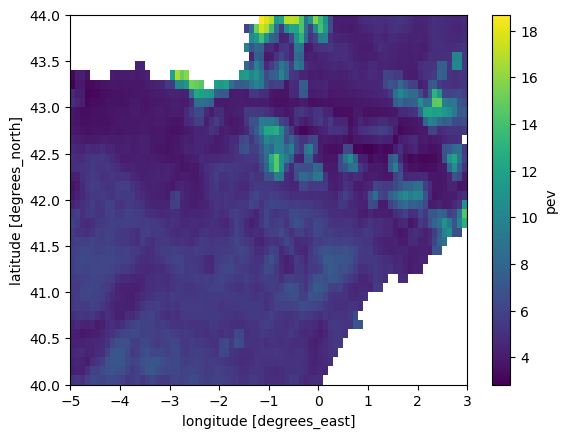

In [26]:
cds_cube_daily.pev.mean(axis=0).plot()

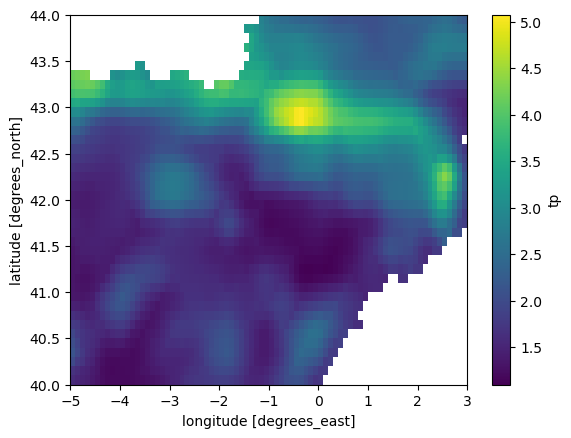

In [27]:
cds_cube_daily.tp.mean(axis=0).plot()

## Resample ERA5 (CDS) and LC to Soil Moisture (CLMS) grid

In [28]:
gm_sm = GridMapping.from_dataset(soil_moisture)

gm_cds = GridMapping.from_dataset(cds_cube_daily)

gm_lc = GridMapping.from_dataset(lc_binary.to_dataset(name="lc_binary"))

print(gm_sm, gm_cds, gm_lc)

<xcube_resampling.gridmapping.regular.RegularGridMapping object at 0x7c34b3686750> <xcube_resampling.gridmapping.regular.RegularGridMapping object at 0x7c34b02ee3c0> <xcube_resampling.gridmapping.regular.RegularGridMapping object at 0x7c34b058ba70>


In [29]:
cds_in_gm_sm = resample_in_space(cds_cube_daily, target_gm = gm_sm)
cds_in_gm_sm = cds_in_gm_sm.assign_coords(time=cds_cube_daily.time) # this step is needed until resample_in_space is fixed
cds_in_gm_sm

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 731, lat: 448, lon: 896)
Coordinates:
    spatial_ref  int64 8B 0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    pev          (time, lat, lon) float32 1GB dask.array<chunksize=(1, 128, 128), meta=np.ndarray>
    tp           (time, lat, lon) float32 1GB dask.array<chunksize=(1, 128, 128), meta=np.ndarray>

In [30]:
lc_binary.attrs['flag_values'] = [0, 1]
lc_binary.attrs['flag_meanings'] = "no_data croplands_land_cover"
lc_in_gm_sm = resample_in_space(lc_binary.to_dataset(name="lc_binary"), target_gm = gm_sm, agg_methods="mode")
lc_in_gm_sm=lc_in_gm_sm.drop_vars('time')
lc_in_gm_sm

<xarray.Dataset> Size: 412kB
Dimensions:      (lat: 448, lon: 896)
Coordinates:
    spatial_ref  int64 8B 0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
Data variables:
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(128, 128), meta=np.ndarray>

In [31]:
print(GridMapping.from_dataset(cds_in_gm_sm), GridMapping.from_dataset(lc_in_gm_sm))

<xcube_resampling.gridmapping.regular.RegularGridMapping object at 0x7c34dcfda600> <xcube_resampling.gridmapping.regular.RegularGridMapping object at 0x7c34b370ff80>


## Masking the data to Ebro Basin and only landcover classes for croplands

In [32]:
cds_masked_full = cds_in_gm_sm.where(lc_in_gm_sm.lc_binary == 1)
cds_masked = mask_dataset_by_geometry(cds_masked_full, gdf.geometry[0])

soil_moisture_masked_full = soil_moisture.where(lc_in_gm_sm.lc_binary == 1)
soil_moisture_masked = mask_dataset_by_geometry(soil_moisture_masked_full, gdf.geometry[0])

## Align and merge all these dataset variables into one cube

In [33]:
soil_moisture_masked = chunk_dataset(soil_moisture_masked, chunk_sizes={"time":-1})
cds_masked = chunk_dataset(cds_masked, chunk_sizes={"time":-1})

In [34]:
ds_combined = xr.merge([soil_moisture_masked, cds_masked, lc_in_gm_sm]) 
ds_combined

/tmp/ipykernel_1306134/3937631259.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lat' ('lat',) The recommendation is to set join explicitly for this case.
  ds_combined = xr.merge([soil_moisture_masked, cds_masked, lc_in_gm_sm])
/tmp/ipykernel_1306134/3937631259.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lon' ('lon',) The recommendation is to set join explicitly for this case.
  ds_combined = xr.merge([soil_moisture_masked, cds_masked, lc_in_gm_sm])
/tmp/ipykernel_1306134/3937631259.py:1: FutureWa

<xarray.Dataset> Size: 5GB
Dimensions:      (lat: 448, lon: 896, time: 731)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
    spatial_ref  int64 8B 0
Data variables:
    SWI          (time, lat, lon) float64 2GB dask.array<chunksize=(731, 53, 61), meta=np.ndarray>
    pev          (time, lat, lon) float32 1GB dask.array<chunksize=(731, 53, 61), meta=np.ndarray>
    tp           (time, lat, lon) float32 1GB dask.array<chunksize=(731, 53, 61), meta=np.ndarray>
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(112, 128), meta=np.ndarray>
Attributes:
    geospatial_lon_units:       degrees_east
    geospatial_lon_min:         -4.410714287500187
    geospatial_lon_max:         2.160714287499627
    geospatial_lon_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lat_min:         40.339285712498786
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_resolution:  0.008928575
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    date_modified:              2025-09-26T11:09:40.381295

In [35]:
chunked_ds = chunk_dataset(ds_combined, chunk_sizes={"time":-1, "lat":128, "lon":128}, format_name="zarr")
chunked_ds

<xarray.Dataset> Size: 5GB
Dimensions:      (lat: 448, lon: 896, time: 731)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
    spatial_ref  int64 8B 0
Data variables:
    SWI          (time, lat, lon) float64 2GB dask.array<chunksize=(731, 128, 128), meta=np.ndarray>
    pev          (time, lat, lon) float32 1GB dask.array<chunksize=(731, 128, 128), meta=np.ndarray>
    tp           (time, lat, lon) float32 1GB dask.array<chunksize=(731, 128, 128), meta=np.ndarray>
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(128, 128), meta=np.ndarray>
Attributes:
    geospatial_lon_units:       degrees_east
    geospatial_lon_min:         -4.410714287500187
    geospatial_lon_max:         2.160714287499627
    geospatial_lon_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lat_min:         40.339285712498786
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_resolution:  0.008928575
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    date_modified:              2025-09-26T11:09:40.381295

In [36]:
%%time

irr_store.write_data(chunked_ds, "irrigation_input.zarr")

CPU times: user 10min 38s, sys: 20 s, total: 10min 58s
Wall time: 9min 20s


'irrigation_input.zarr'

In [37]:
irrigation_input=irr_store.open_data("irrigation_input.zarr")
irrigation_input

<xarray.Dataset> Size: 5GB
Dimensions:      (time: 731, lat: 448, lon: 896)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B ...
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    SWI          (time, lat, lon) float64 2GB dask.array<chunksize=(731, 128, 128), meta=np.ndarray>
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(128, 128), meta=np.ndarray>
    pev          (time, lat, lon) float32 1GB dask.array<chunksize=(731, 128, 128), meta=np.ndarray>
    tp           (time, lat, lon) float32 1GB dask.array<chunksize=(731, 128, 128), meta=np.ndarray>
Attributes:
    date_modified:              2025-09-26T11:09:40.381295
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    geospatial_bounds_crs:      CRS84
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_min:         40.339285712498786
    geospatial_lat_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lon_max:         2.160714287499627
    geospatial_lon_min:         -4.410714287500187
    geospatial_lon_resolution:  0.008928575
    geospatial_lon_units:       degrees_east

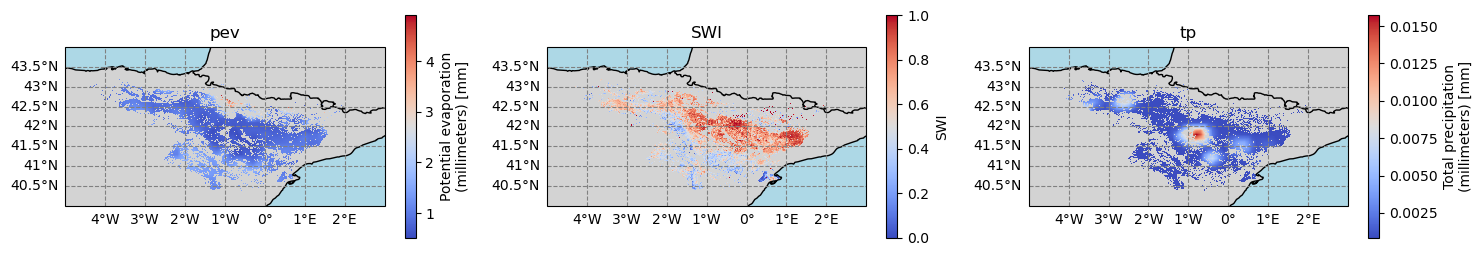

CPU times: user 9.99 s, sys: 4.73 s, total: 14.7 s
Wall time: 4.69 s


In [39]:
%%time

ds = irrigation_input.isel(time=5)
vars_to_plot = ["pev", "SWI", "tp"]

proj = ccrs.PlateCarree()
n_vars = len(vars_to_plot)
n_cols = 3
n_rows = -(-n_vars // n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5*n_cols, 4*n_rows),
    subplot_kw={"projection": proj}
)

for ax, var in zip(axes.flat, vars_to_plot):
    da = ds[var]
    da.plot(ax=ax, transform=proj, cmap="coolwarm", cbar_kwargs={"shrink": 0.6})
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.set_title(var)
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
    gl.top_labels = False
    gl.right_labels = False


plt.tight_layout()
plt.show()